# Glove Gesture ML Explorer

Configurable pipeline for exploring hand gesture recognition from the sensory glove dataset.

**Workflow:**
1. [Config](#1-configuration) — Set data path, select columns, labels, and splits
2. [Load Data](#2-data-loading) — Read CSVs, attach labels from folder names
3. [Preprocess](#3-preprocessing) — Filter, normalise, extract features
4. [Train & Evaluate](#4-training--evaluation) — Run selected ML algorithms
5. [Results](#5-results-comparison) — Compare algorithms side-by-side

---
**Dataset structure:**  
Each folder under `DATA_ROOT` is a gesture label (e.g. `TwoHand_L_Fist_R_Fist`).  
Each CSV = one 5-second trial at ~22 Hz → ~110 rows × 295 columns.

> **Note on `TwoHand_L_Flat_R_Flat`:** Files in this folder are named `*L_Fist_R_Fist*` by mistake — they are Flat gestures. The label is taken from the **folder name**, not the filename, so this is handled correctly automatically.

---
## 0. Install / Import Dependencies

In [91]:
# Run once to install any missing packages
import subprocess, sys
pkgs = ['scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs)
print('Dependencies ready.')

Dependencies ready.


In [92]:
import os, glob, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

# Classifiers
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
print('Imports OK.')

Imports OK.


---
## 1. Configuration

**Edit this cell to control the entire pipeline.**

In [ ]:
# =============================================================================
# 1A. DATA PATH
# =============================================================================
# Path to the root folder containing gesture subfolders (ThesisA.data).
# Each subfolder name becomes the class label.
# Accepts absolute paths or paths relative to this notebook.
DATA_ROOT = '/home/jestin/ThesisRepo/ML/NewTrainingData/Static'   # <-- change this to point to your data folder

# /home/jestin/ThesisData/TrainingData/Raw



# Labels to INCLUDE. Set to None to use ALL subfolders automatically.
# Example: INCLUDE_LABELS = ['TwoHand_L_Fist_R_Fist', 'TwoHand_L_Flat_R_Flat']
INCLUDE_LABELS = None

# =============================================================================
# 1B. COLUMN SELECTION
# =============================================================================
# Choose which sensor modalities to include.
# Each flag independently includes/excludes that group of columns.

USE_YAW_PITCH_ROLL   = True    # IMU Euler angles (yaw, pitch, roll / heading)
USE_QUATERNIONS      = False   # Raw quaternion components (quat_w/x/y/z)
                               # Note: for TwoHand_L_Flat_R_Flat, quaternions are
                               #       the primary data — pitch/roll/yaw are derived.
                               #       Set True if using that label.
USE_ACCELEROMETER    = True    # Linear accelerometer (ax, ay, az)
USE_FLEX_SENSORS     = True    # Flex sensor readings (mcp_flex, pip_flex)

# Choose which body segments to include.
# Available: 'palm_prox', 'thumb', 'index', 'middle', 'ring', 'pinky', 'wrist'
# 'palm_mid'  = excluded — IMU columns exist in CSV but contain no sensor data
# 'palm_prox' = IMU on back of palm (proximal, near wrist)
# 'wrist'     = IMU at end of forearm closest to wrist
# Note: flex sensors exist for fingers only (thumb, index, middle, ring, pinky) — NOT palm
INCLUDE_SEGMENTS = [
    'palm_mid',  # excluded: IMU columns exist but contain no data
    # 'palm_prox',
    'thumb',
    'index',
    'middle',
    'ring',
    'pinky',
    'wrist',
]

# Choose which hands to include
INCLUDE_HANDS = ['left', 'right']  # options: 'left', 'right', or both

# =============================================================================
# 1C. PREPROCESSING
# =============================================================================

# --- Resampling ---
# Resample each trial to a fixed number of time steps (handles variable-length files).
# Set to None to skip resampling (all files must then have the same row count).
RESAMPLE_TO_N_STEPS = 90      # target number of rows per trial

# --- Low-pass Butterworth filter ---
APPLY_BUTTERWORTH    = True     # Apply low-pass filter to smooth IMU noise
BUTTERWORTH_CUTOFF   = 5.0      # Cutoff frequency in Hz
BUTTERWORTH_ORDER    = 4        # Filter order
SAMPLING_RATE_HZ     = 30.0     # Approximate sampling rate of the glove

# --- Normalisation ---
# 'standard'  → zero mean, unit variance (StandardScaler) — good for SVM, LDA
# 'minmax'    → scale to [0, 1]  (MinMaxScaler) — good for KNN, neural nets
# None        → no normalisation
NORMALISATION = 'standard'

# --- Feature extraction mode ---
# 'flatten'    → use the raw resampled time series as a flat feature vector
#                (n_steps × n_channels features per sample)
# 'stats'      → extract statistical features per channel
#                (mean, std, min, max, range, RMS, skew, kurtosis)
# 'fft'        → FFT magnitude spectrum per channel
# 'stats+fft'  → combine statistical + FFT features
FEATURE_MODE = 'stats'    # Recommended starting point

# =============================================================================
# 1D. TRAIN / TEST SPLIT
# =============================================================================
TEST_SIZE        = 0.2    # Fraction of data held out for testing
RANDOM_STATE     = 42
CV_FOLDS         = 10      # Number of cross-validation folds

# =============================================================================
# 1E. ALGORITHMS
# =============================================================================
# Set True/False to include/exclude each algorithm.
ALGORITHMS = {
    'SVM (RBF)'           : True,
    'SVM (Linear)'        : True,
    'Random Forest'       : True,
    'KNN'                 : True,
    'Gradient Boosting'   : False,   # Slower — enable when needed
    'Logistic Regression' : True,
    'LDA'                 : True,
}

print('Configuration loaded.')
print(f'  Data root  : {DATA_ROOT}')
print(f'  Hands      : {INCLUDE_HANDS}')
print(f'  Segments   : {INCLUDE_SEGMENTS}')
print(f'  Modalities : YPR={USE_YAW_PITCH_ROLL}, Quat={USE_QUATERNIONS}, Accel={USE_ACCELEROMETER}, Flex={USE_FLEX_SENSORS}')
print(f'  Features   : {FEATURE_MODE}')
print(f'  Algorithms : {[k for k,v in ALGORITHMS.items() if v]}')

Configuration loaded.
  Data root  : /home/jestin/ThesisRepo/ML/NewTrainingData/Static
  Hands      : ['left', 'right']
  Segments   : ['palm_mid', 'thumb', 'index', 'middle', 'ring', 'pinky', 'wrist']
  Modalities : YPR=True, Quat=False, Accel=True, Flex=True
  Features   : stats
  Algorithms : ['SVM (RBF)', 'SVM (Linear)', 'Random Forest', 'KNN', 'Logistic Regression', 'LDA']


---
## 2. Data Loading

In [133]:
# ── Build column selector from config ─────────────────────────────────────────

# All 295 columns, grouped by type for easy selection
META_COLS = [
    'run_index', 'request_id', 'request_ts',
    'right_recv_time_ms', 'right_glove_time_ms', 'right_time',
    'left_recv_time_ms',  'left_glove_time_ms',  'left_time',
    'left_hand', 'right_hand'
]

SEGMENTS_WITH_FLEX = ['thumb', 'index', 'middle', 'ring', 'pinky']  # palm has no flex sensors
IMU_LOCATIONS = ['mid', 'prox']  # distal phalanx / proximal phalanx

def build_sensor_columns(hands, segments, use_ypr, use_quat, use_accel, use_flex):
    """Return list of sensor column names matching the user config."""
    cols = []
    for hand in hands:
        for seg in segments:
            # Determine IMU sub-locations for this segment
            # palm has mid + prox; all finger segments have mid + prox; wrist has no sub-location
            if seg == 'wrist':
                prefix = f'{hand}_wrist'
                if use_ypr:
                    cols += [f'{prefix}_heading', f'{prefix}_pitch', f'{prefix}_roll']
                if use_quat:
                    cols += [f'{prefix}_quat_w', f'{prefix}_quat_x',
                             f'{prefix}_quat_y', f'{prefix}_quat_z']
                if use_accel:
                    cols += [f'{prefix}_ax', f'{prefix}_ay', f'{prefix}_az']
                # wrist has no flex sensor
            else:
                # segment has mid + prox IMU positions
                # For 'thumb','index' etc, map to e.g. 'left_thumb_mid_yaw'
                for loc in ['mid', 'prox']:
                    prefix = f'{hand}_{seg}_{loc}'
                    if use_ypr:
                        cols += [f'{prefix}_yaw', f'{prefix}_pitch', f'{prefix}_roll']
                    if use_quat:
                        cols += [f'{prefix}_quat_w', f'{prefix}_quat_x',
                                 f'{prefix}_quat_y', f'{prefix}_quat_z']
                    if use_accel:
                        cols += [f'{prefix}_ax', f'{prefix}_ay', f'{prefix}_az']
                # Flex sensors (one per finger joint combination, not per loc)
                if use_flex and seg in ['thumb', 'index', 'middle', 'ring', 'pinky']:  # palm has no flex
                    cols += [f'{hand}_{seg}_mcp_flex', f'{hand}_{seg}_pip_flex']
    return cols

# Map user-friendly segment names to CSV naming convention
seg_map = {
    'palm_mid':  'palm',   # excluded by default — no sensor data on palm_mid
    'palm_prox': 'palm',   # deduplicated below
    'thumb':     'thumb',
    'index':     'index',
    'middle':    'middle',
    'ring':      'ring',
    'pinky':     'pinky',
    'wrist':     'wrist',
}

# Resolve segments, de-duplicating palm if both palm_mid and palm_prox selected
resolved_segs = list(dict.fromkeys([seg_map[s] for s in INCLUDE_SEGMENTS]))

SENSOR_COLS = build_sensor_columns(
    hands    = INCLUDE_HANDS,
    segments = resolved_segs,
    use_ypr  = USE_YAW_PITCH_ROLL,
    use_quat = USE_QUATERNIONS,
    use_accel= USE_ACCELEROMETER,
    use_flex = USE_FLEX_SENSORS
)

print(f'Selected {len(SENSOR_COLS)} sensor columns.')
print('First 10:', SENSOR_COLS[:10])
print('Last 10:', SENSOR_COLS[-10:])

Selected 176 sensor columns.
First 10: ['left_palm_mid_yaw', 'left_palm_mid_pitch', 'left_palm_mid_roll', 'left_palm_mid_ax', 'left_palm_mid_ay', 'left_palm_mid_az', 'left_palm_prox_yaw', 'left_palm_prox_pitch', 'left_palm_prox_roll', 'left_palm_prox_ax']
Last 10: ['right_pinky_prox_ay', 'right_pinky_prox_az', 'right_pinky_mcp_flex', 'right_pinky_pip_flex', 'right_wrist_heading', 'right_wrist_pitch', 'right_wrist_roll', 'right_wrist_ax', 'right_wrist_ay', 'right_wrist_az']


In [134]:
# ── Load all CSV files ─────────────────────────────────────────────────────────

def load_dataset(data_root, include_labels, sensor_cols):
    """Load all CSVs from label subfolders. Returns list of (df_trial, label)."""
    data_root = os.path.expanduser(data_root)
    if not os.path.isdir(data_root):
        raise FileNotFoundError(
            f"DATA_ROOT not found: '{data_root}'\n"
            "Please update DATA_ROOT in the Configuration cell to point to your "
            "ThesisA.data folder."
        )

    label_dirs = sorted([
        d for d in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, d))
        and d not in ('PDF', 'sdb', 'idk')  # skip non-gesture folders
    ])

    if include_labels is not None:
        label_dirs = [d for d in label_dirs if d in include_labels]

    if not label_dirs:
        raise ValueError('No label folders found. Check DATA_ROOT and INCLUDE_LABELS.')

    print(f'Found {len(label_dirs)} gesture classes:')
    trials, labels = [], []

    for label in label_dirs:
        folder = os.path.join(data_root, label)
        csv_files = sorted(glob.glob(os.path.join(folder, '*.csv')))
        print(f'  [{label}]  →  {len(csv_files)} files')
        for fpath in csv_files:
            try:
                df = pd.read_csv(fpath)
                # Keep only sensor columns that exist in this file
                available = [c for c in sensor_cols if c in df.columns]
                if not available:
                    print(f'    WARNING: no matching sensor columns in {os.path.basename(fpath)}')
                    continue
                trials.append(df[available].values.astype(np.float32))
                labels.append(label)
            except Exception as e:
                print(f'    ERROR loading {os.path.basename(fpath)}: {e}')

    print(f'\nTotal trials loaded: {len(trials)}')
    return trials, labels, label_dirs

trials_raw, labels_raw, class_names = load_dataset(
    DATA_ROOT, INCLUDE_LABELS, SENSOR_COLS
)

# Class distribution
from collections import Counter
print('\nClass distribution:')
for cls, cnt in sorted(Counter(labels_raw).items()):
    print(f'  {cls}: {cnt} trials')

Found 7 gesture classes:
  [Double_Closed_Fist]  →  65 files
  [Double_Nothing]  →  60 files
  [Double_Okay]  →  60 files
  [Double_Open_Palm]  →  60 files
  [Double_Phone]  →  60 files
  [Double_Pistol]  →  60 files
  [Double_Spiderman]  →  60 files

Total trials loaded: 425

Class distribution:
  Double_Closed_Fist: 65 trials
  Double_Nothing: 60 trials
  Double_Okay: 60 trials
  Double_Open_Palm: 60 trials
  Double_Phone: 60 trials
  Double_Pistol: 60 trials
  Double_Spiderman: 60 trials


---
## 3. Preprocessing

In [135]:
# ── Step 1: Resample to fixed length ──────────────────────────────────────────

def resample_trial(trial, n_steps):
    """Resample a (T, C) array to (n_steps, C) using linear interpolation."""
    T, C = trial.shape
    if T == n_steps:
        return trial
    old_idx = np.linspace(0, 1, T)
    new_idx = np.linspace(0, 1, n_steps)
    resampled = np.zeros((n_steps, C), dtype=np.float32)
    for c in range(C):
        resampled[:, c] = np.interp(new_idx, old_idx, trial[:, c])
    return resampled

if RESAMPLE_TO_N_STEPS is not None:
    trials_resampled = [resample_trial(t, RESAMPLE_TO_N_STEPS) for t in trials_raw]
    print(f'Resampled all trials to {RESAMPLE_TO_N_STEPS} time steps.')
else:
    trials_resampled = trials_raw
    lengths = [t.shape[0] for t in trials_resampled]
    print(f'No resampling. Trial lengths: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}')
    if min(lengths) != max(lengths):
        print('  WARNING: Variable-length trials detected. Enable RESAMPLE_TO_N_STEPS '
              'or use a feature extraction mode that handles variable length.')

print(f'Trial shape: {trials_resampled[0].shape}  (time_steps × channels)')

Resampled all trials to 90 time steps.
Trial shape: (90, 176)  (time_steps × channels)


In [136]:
# ── Step 2: Butterworth low-pass filter ───────────────────────────────────────

def apply_butterworth(trials, cutoff, order, fs):
    """Apply a zero-phase Butterworth low-pass filter to each channel of each trial."""
    nyq = fs / 2.0
    norm_cutoff = cutoff / nyq
    if norm_cutoff >= 1.0:
        print(f'  WARNING: cutoff {cutoff} Hz >= Nyquist {nyq} Hz — skipping filter.')
        return trials
    b, a = scipy_signal.butter(order, norm_cutoff, btype='low', analog=False)
    filtered = []
    for t in trials:
        t_filt = scipy_signal.filtfilt(b, a, t, axis=0).astype(np.float32)
        filtered.append(t_filt)
    return filtered

if APPLY_BUTTERWORTH:
    trials_filtered = apply_butterworth(
        trials_resampled, BUTTERWORTH_CUTOFF, BUTTERWORTH_ORDER, SAMPLING_RATE_HZ
    )
    print(f'Applied Butterworth low-pass filter: {BUTTERWORTH_CUTOFF} Hz cutoff, '
          f'order {BUTTERWORTH_ORDER}, Nyquist = {SAMPLING_RATE_HZ/2} Hz')
else:
    trials_filtered = trials_resampled
    print('Butterworth filter skipped.')

Applied Butterworth low-pass filter: 5.0 Hz cutoff, order 4, Nyquist = 15.0 Hz


In [137]:
# ── Step 3: Feature extraction ────────────────────────────────────────────────

def extract_stats(trial):
    """Statistical features per channel: mean, std, min, max, range, RMS, skew, kurtosis."""
    feats = np.concatenate([
        trial.mean(axis=0),
        trial.std(axis=0),
        trial.min(axis=0),
        trial.max(axis=0),
        trial.max(axis=0) - trial.min(axis=0),          # range
        np.sqrt((trial**2).mean(axis=0)),                # RMS
        skew(trial, axis=0).astype(np.float32),
        kurtosis(trial, axis=0).astype(np.float32),
    ])
    return feats

def extract_fft(trial, fs):
    """FFT magnitude features per channel (first half of spectrum)."""
    n = trial.shape[0]
    fft_mag = np.abs(np.fft.rfft(trial, axis=0))  # shape: (n//2+1, C)
    return fft_mag.flatten().astype(np.float32)

def extract_features(trials, mode, fs):
    X = []
    for t in trials:
        if mode == 'flatten':
            feats = t.flatten()
        elif mode == 'stats':
            feats = extract_stats(t)
        elif mode == 'fft':
            feats = extract_fft(t, fs)
        elif mode == 'stats+fft':
            feats = np.concatenate([extract_stats(t), extract_fft(t, fs)])
        else:
            raise ValueError(f'Unknown FEATURE_MODE: {mode}')
        X.append(feats)
    return np.array(X, dtype=np.float32)

X = extract_features(trials_filtered, FEATURE_MODE, SAMPLING_RATE_HZ)

# ── NaN / Inf cleanup ─────────────────────────────────────────────────────────
# Constant channels (e.g. palm_mid, palm flex) produce NaN in skew/kurtosis
# Replace with 0 — constant channels carry no class information anyway
bad = np.isnan(X) | np.isinf(X)
if bad.any():
    print(f'WARNING: {bad.sum()} NaN/Inf values found — replacing with 0.')
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f'Feature matrix shape: {X.shape}  ({X.shape[0]} trials × {X.shape[1]} features)')

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels_raw)
print(f'Labels encoded: {dict(zip(le.classes_, range(len(le.classes_))))}')

Feature matrix shape: (425, 1408)  (425 trials × 1408 features)
Labels encoded: {np.str_('Double_Closed_Fist'): 0, np.str_('Double_Nothing'): 1, np.str_('Double_Okay'): 2, np.str_('Double_Open_Palm'): 3, np.str_('Double_Phone'): 4, np.str_('Double_Pistol'): 5, np.str_('Double_Spiderman'): 6}


In [138]:
# ── Step 4: Normalise + split ─────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

if NORMALISATION == 'standard':
    scaler = StandardScaler()
elif NORMALISATION == 'minmax':
    scaler = MinMaxScaler()
else:
    scaler = None

if scaler is not None:
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    print(f'Applied {NORMALISATION} normalisation.')
else:
    print('No normalisation applied.')

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Applied standard normalisation.
Train: 340 samples | Test: 85 samples


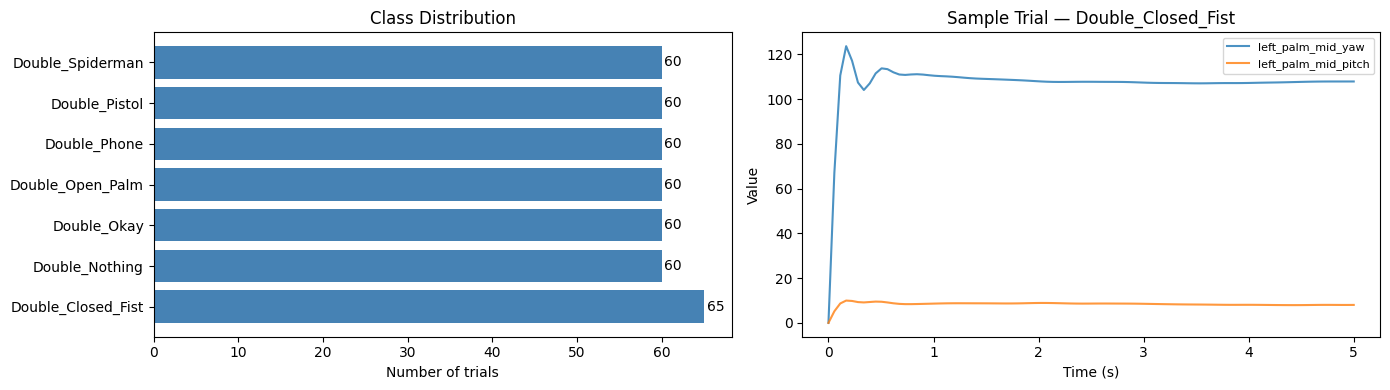

In [139]:
# ── Quick data visualisation: class distribution ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution
label_counts = pd.Series(labels_raw).value_counts()
axes[0].barh(label_counts.index, label_counts.values, color='steelblue')
axes[0].set_xlabel('Number of trials')
axes[0].set_title('Class Distribution')
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 0.3, i, str(v), va='center')

# Sample trial: first two channels
sample = trials_filtered[0]
t_axis = np.linspace(0, 5, sample.shape[0])
axes[1].plot(t_axis, sample[:, 0], label=SENSOR_COLS[0], alpha=0.8)
if sample.shape[1] > 1:
    axes[1].plot(t_axis, sample[:, 1], label=SENSOR_COLS[1], alpha=0.8)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Value')
axes[1].set_title(f'Sample Trial — {labels_raw[0]}')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Training & Evaluation

In [140]:
# ── Define classifiers from config ────────────────────────────────────────────

CLASSIFIER_DEFS = {
    'SVM (RBF)':           SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE),
    'SVM (Linear)':        SVC(kernel='linear', C=1, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'LDA':                 LinearDiscriminantAnalysis(),
}

active_classifiers = {k: v for k, v in CLASSIFIER_DEFS.items() if ALGORITHMS.get(k, False)}
print(f'Running {len(active_classifiers)} algorithms: {list(active_classifiers.keys())}')

Running 6 algorithms: ['SVM (RBF)', 'SVM (Linear)', 'Random Forest', 'KNN', 'Logistic Regression', 'LDA']


In [141]:
# ── Print model parameters for all active classifiers ─────────────────────────
# Shows every hyperparameter and (after training) learned model properties.

PARAM_DESCRIPTIONS = {
    # SVM
    'C':               'Regularisation — higher = fits training data more tightly, lower = wider margin (less overfit)',
    'kernel':          'Decision boundary shape: rbf=curved (non-linear), linear=flat hyperplane',
    'gamma':           'RBF kernel width — scale=1/(n_features*X.var()), auto=1/n_features. Higher=more complex boundary',
    # Random Forest
    'n_estimators':    'Number of decision trees in the forest — more trees = more stable, slower',
    'max_depth':       'Max tree depth — None=grow until pure leaves (may overfit)',
    'min_samples_split':'Min samples required to split a node — higher=simpler trees',
    'min_samples_leaf': 'Min samples required at a leaf — higher=smoother decision boundary',
    'max_features':    'Features considered per split — sqrt=sqrt(n_features), None=all features',
    # KNN
    'n_neighbors':     'Number of nearest neighbours to vote — lower=more sensitive to noise, higher=smoother boundary',
    'metric':          'Distance measure used to find neighbours',
    'weights':         'uniform=all neighbours equal vote, distance=closer neighbours weighted more',
    # Logistic Regression
    'max_iter':        'Maximum solver iterations — increase if convergence warning appears',
    'C':               'Inverse regularisation strength — higher=less regularisation (fits training harder)',
    'solver':          'Optimisation algorithm used to fit the model',
    'multi_class':     'Strategy for multi-class: auto selects ovr or multinomial',
    # LDA
    'solver':          'svd=no matrix inversion (stable), lsqr/eigen=faster but less stable',
    'shrinkage':       'Regularisation on covariance matrix — None=no shrinkage',
    'n_components':    'Dimensions to reduce to — None=min(n_classes-1, n_features)',
    # Gradient Boosting
    'learning_rate':   'Shrinks each tree contribution — lower=more trees needed but better generalisation',
    'subsample':       'Fraction of samples per tree — <1.0 adds randomness (stochastic boosting)',
}

print('=' * 70)
print('CLASSIFIER PARAMETERS')
print('=' * 70)

for name, clf in active_classifiers.items():
    params = clf.get_params()
    print(f'\n┌─ {name} ─────────────────────────────────────────')
    print(f'│  Type: {type(clf).__name__}')
    print(f'│')
    for param, value in params.items():
        desc = PARAM_DESCRIPTIONS.get(param, '')
        desc_str = f'  # {desc}' if desc else ''
        print(f'│  {param:<22} = {str(value):<15}{desc_str}')
    print(f'└──────────────────────────────────────────────────')

# ── Post-training learned properties (run after Section 4 training cell) ─────
print()
print('=' * 70)
print('POST-TRAINING LEARNED PROPERTIES  (run after Section 4)')
print('=' * 70)

if 'results' not in dir():
    print('  Classifiers not yet trained — run Section 4 first.')
else:
    for name, res in results.items():
        clf = res['clf']
        print(f'\n  {name}:')

        if hasattr(clf, 'support_vectors_'):
            n_sv = clf.support_vectors_.shape[0]
            pct  = 100 * n_sv / len(X_train)
            print(f'    Support vectors : {n_sv} / {len(X_train)} training samples ({pct:.1f}%)')
            print(f'    (Low % = confident, wide margin. High % = decision boundary uncertain)')

        if hasattr(clf, 'n_iter_'):
            print(f'    Iterations      : {clf.n_iter_}')

        if hasattr(clf, 'feature_importances_'):
            fi   = clf.feature_importances_
            top3 = fi.argsort()[::-1][:3]
            print(f'    Feature importances (top 3 feature indices): {top3}')
            print(f'    Top 3 importance values: {fi[top3].round(4)}')

        if hasattr(clf, 'coef_'):
            coef = clf.coef_
            print(f'    Coefficient matrix shape: {coef.shape}  ({coef.shape[0]} classes × {coef.shape[1]} features)')
            print(f'    Coef magnitude  : mean={abs(coef).mean():.4f}, max={abs(coef).max():.4f}')

        if hasattr(clf, 'scalings_'):
            print(f'    LDA scalings shape: {clf.scalings_.shape}  ({clf.scalings_.shape[1]} discriminant axes)')
            print(f'    Explained variance ratio: {clf.explained_variance_ratio_.round(4) if hasattr(clf, "explained_variance_ratio_") else "N/A"}')
        if hasattr(clf, 'estimators_') and name == 'Random Forest':
            depths = [e.get_depth() for e in clf.estimators_]
            print(f'    Trees grown     : {len(clf.estimators_)}')
            print(f'    Tree depth      : mean={sum(depths)/len(depths):.1f}, max={max(depths)}, min={min(depths)}')


CLASSIFIER PARAMETERS

┌─ SVM (RBF) ─────────────────────────────────────────
│  Type: SVC
│
│  C                      = 10               # Inverse regularisation strength — higher=less regularisation (fits training harder)
│  break_ties             = False          
│  cache_size             = 200            
│  class_weight           = None           
│  coef0                  = 0.0            
│  decision_function_shape = ovr            
│  degree                 = 3              
│  gamma                  = scale            # RBF kernel width — scale=1/(n_features*X.var()), auto=1/n_features. Higher=more complex boundary
│  kernel                 = rbf              # Decision boundary shape: rbf=curved (non-linear), linear=flat hyperplane
│  max_iter               = -1               # Maximum solver iterations — increase if convergence warning appears
│  probability            = False          
│  random_state           = 42             
│  shrinking              = True           


In [142]:
# ── Train, cross-validate, and test each classifier ───────────────────────────

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
# cv = StratifiedGroupKFold(n_splits=CV_FOLDS,shuffle=True,random_state=RANDOM_STATE)
results = {}

for name, clf in active_classifiers.items():
    print(f'\n--- {name} ---')

    # Cross-validation on training set
    cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'  CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    # Fit on full training set
    clf.fit(X_train, y_train)

    # Test set evaluation
    y_pred = clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    print(f'  Test accuracy: {test_acc:.4f}')

    results[name] = {
        'cv_mean':    cv_scores.mean(),
        'cv_std':     cv_scores.std(),
        'test_acc':   test_acc,
        'y_pred':     y_pred,
        'clf':        clf,
    }

print('\n✓ All classifiers trained.')


--- SVM (RBF) ---
  CV accuracy: 0.9824 ± 0.0195
  Test accuracy: 1.0000

--- SVM (Linear) ---
  CV accuracy: 0.9971 ± 0.0088
  Test accuracy: 1.0000

--- Random Forest ---
  CV accuracy: 0.9971 ± 0.0088
  Test accuracy: 1.0000

--- KNN ---
  CV accuracy: 0.9676 ± 0.0404
  Test accuracy: 0.9765

--- Logistic Regression ---
  CV accuracy: 0.9971 ± 0.0088
  Test accuracy: 1.0000

--- LDA ---
  CV accuracy: 0.9941 ± 0.0118
  Test accuracy: 1.0000

✓ All classifiers trained.


In [143]:
# ── Per-class classification reports ─────────────────────────────────────────

for name, res in results.items():
    print(f'\n=== {name} ===')
    print(classification_report(
        y_test, res['y_pred'],
        target_names=le.classes_,
        zero_division=0
    ))


=== SVM (RBF) ===
                    precision    recall  f1-score   support

Double_Closed_Fist       1.00      1.00      1.00        13
    Double_Nothing       1.00      1.00      1.00        12
       Double_Okay       1.00      1.00      1.00        12
  Double_Open_Palm       1.00      1.00      1.00        12
      Double_Phone       1.00      1.00      1.00        12
     Double_Pistol       1.00      1.00      1.00        12
  Double_Spiderman       1.00      1.00      1.00        12

          accuracy                           1.00        85
         macro avg       1.00      1.00      1.00        85
      weighted avg       1.00      1.00      1.00        85


=== SVM (Linear) ===
                    precision    recall  f1-score   support

Double_Closed_Fist       1.00      1.00      1.00        13
    Double_Nothing       1.00      1.00      1.00        12
       Double_Okay       1.00      1.00      1.00        12
  Double_Open_Palm       1.00      1.00      1.00      

---
## 5. Data Diagnostics

Quantifies **within-class consistency** and **between-class separation** of the loaded dataset.
Run this after preprocessing to understand how separable your gestures are before training.

- **Within-class cosine similarity** — how alike trials of the same gesture are (1.0 = identical)
- **Separation ratio** — between-class distance ÷ within-class spread. Higher = easier to classify.
- **t-SNE plot** — 2D projection of the feature space to visually confirm class clustering.

WITHIN-CLASS TRIAL SIMILARITY  (cosine, 1.0 = identical)
  Double_Closed_Fist         mean=0.9959  min=0.9887  feat_std=11.95
  Double_Nothing             mean=0.9941  min=0.9876  feat_std=19.80
  Double_Okay                mean=0.9959  min=0.9900  feat_std=10.79
  Double_Open_Palm           mean=0.9918  min=0.9761  feat_std=11.62
  Double_Phone               mean=0.9935  min=0.9846  feat_std=15.73
  Double_Pistol              mean=0.9943  min=0.9839  feat_std=13.36
  Double_Spiderman           mean=0.9955  min=0.9878  feat_std=12.95

  Interpretation:
    > 0.95  → very consistent (model generalises easily within-session)
    < 0.80  → high variance (harder to learn, more robust to new sessions)

BETWEEN-CLASS SEPARATION  (ratio = between-dist / within-spread)
  Double_Closed_Fist   vs Double_Nothing        ratio=  110.2x  [trivial]
  Double_Closed_Fist   vs Double_Okay           ratio=  105.1x  [trivial]
  Double_Closed_Fist   vs Double_Open_Palm      ratio=   83.7x  [easy]
  Double_

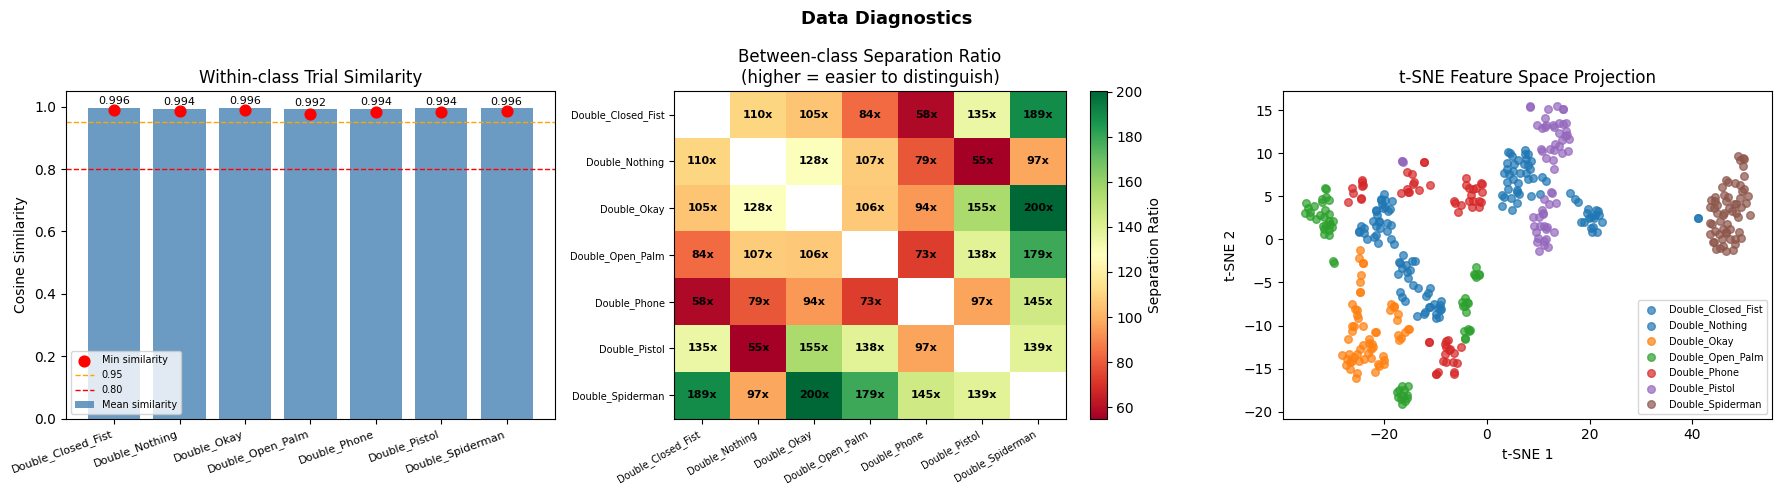

In [144]:
# ── Section 5: Data Diagnostics ───────────────────────────────────────────────
# Runs on the feature matrix X and labels produced in Section 3.
# Must be run after the preprocessing cells.

from sklearn.manifold import TSNE
from itertools import combinations

short_names = [lbl.replace('TwoHandDynamic_','Dyn_').replace('TwoHand_','')
               .replace('_filtered_butterworth_lp','') for lbl in le.classes_]
short_map   = dict(zip(le.classes_, short_names))

# ── 1. Within-class cosine similarity ────────────────────────────────────────
print('=' * 65)
print('WITHIN-CLASS TRIAL SIMILARITY  (cosine, 1.0 = identical)')
print('=' * 65)

within_stats = {}
for cls_id, cls_name in enumerate(le.classes_):
    mask    = (y == cls_id)
    feats   = X[mask]
    norms   = np.linalg.norm(feats, axis=1, keepdims=True)
    feats_n = feats / (norms + 1e-8)
    sim     = feats_n @ feats_n.T
    np.fill_diagonal(sim, np.nan)
    mean_sim = float(np.nanmean(sim))
    min_sim  = float(np.nanmin(sim))
    feat_std = float(feats.std(axis=0).mean())
    within_stats[cls_name] = {'mean_sim': mean_sim, 'min_sim': min_sim, 'feat_std': feat_std}
    print(f'  {short_map[cls_name]:<25}  mean={mean_sim:.4f}  min={min_sim:.4f}  feat_std={feat_std:.2f}')

print()
print('  Interpretation:')
print('    > 0.95  → very consistent (model generalises easily within-session)')
print('    < 0.80  → high variance (harder to learn, more robust to new sessions)')

# ── 2. Between-class separation ratios ───────────────────────────────────────
print()
print('=' * 65)
print('BETWEEN-CLASS SEPARATION  (ratio = between-dist / within-spread)')
print('=' * 65)

class_means  = {cls_name: X[y == cls_id].mean(axis=0)
                for cls_id, cls_name in enumerate(le.classes_)}
pairs        = list(combinations(le.classes_, 2))
ratio_matrix = np.zeros((len(le.classes_), len(le.classes_)))

for cls_a, cls_b in pairs:
    dist   = np.linalg.norm(class_means[cls_a] - class_means[cls_b])
    std_a  = within_stats[cls_a]['feat_std']
    std_b  = within_stats[cls_b]['feat_std']
    ratio  = dist / ((std_a + std_b) / 2)
    idx_a  = list(le.classes_).index(cls_a)
    idx_b  = list(le.classes_).index(cls_b)
    ratio_matrix[idx_a, idx_b] = ratio
    ratio_matrix[idx_b, idx_a] = ratio
    difficulty = ('trivial' if ratio > 100 else
                  'easy'    if ratio > 20  else
                  'moderate'if ratio > 5   else 'hard')
    print(f'  {short_map[cls_a]:<20} vs {short_map[cls_b]:<20}  ratio={ratio:>7.1f}x  [{difficulty}]')

print()
print('  Interpretation:')
print('    > 100x  → trivially separable')
print('    20-100x → easy')
print('    5-20x   → moderate')
print('    < 5x    → hard (expect confusion)')

# ── 3. Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Within-class similarity
ax = axes[0]
names_short = [short_map[c] for c in le.classes_]
means_sim   = [within_stats[c]['mean_sim'] for c in le.classes_]
mins_sim    = [within_stats[c]['min_sim']  for c in le.classes_]
x_pos = np.arange(len(le.classes_))
bars  = ax.bar(x_pos, means_sim, color='steelblue', alpha=0.8, label='Mean similarity')
ax.scatter(x_pos, mins_sim, color='red', zorder=5, label='Min similarity', s=60)
ax.axhline(0.95, color='orange', linestyle='--', linewidth=1, label='0.95')
ax.axhline(0.80, color='red',    linestyle='--', linewidth=1, label='0.80')
ax.set_xticks(x_pos)
ax.set_xticklabels(names_short, rotation=20, ha='right', fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Cosine Similarity')
ax.set_title('Within-class Trial Similarity')
ax.legend(fontsize=7)
for bar, val in zip(bars, means_sim):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Separation ratio heatmap
ax = axes[1]
mask_diag     = np.eye(len(le.classes_), dtype=bool)
ratio_display = ratio_matrix.copy().astype(float)
ratio_display[mask_diag] = np.nan
im = ax.imshow(ratio_display, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax, label='Separation Ratio')
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(names_short, rotation=30, ha='right', fontsize=7)
ax.set_yticklabels(names_short, fontsize=7)
ax.set_title('Between-class Separation Ratio\n(higher = easier to distinguish)')
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if not mask_diag[i, j]:
            ax.text(j, i, f'{ratio_matrix[i,j]:.0f}x',
                    ha='center', va='center', fontsize=8, fontweight='bold')

# Plot 3: t-SNE
ax   = axes[2]
perp = min(30, len(X) // len(le.classes_) - 1)
tsne = TSNE(n_components=2, perplexity=perp, random_state=RANDOM_STATE, max_iter=1000)
X_2d = tsne.fit_transform(X)
colours = plt.cm.tab10(np.linspace(0, 0.5, len(le.classes_)))
for cls_id, (cls_name, col) in enumerate(zip(le.classes_, colours)):
    mask = (y == cls_id)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               label=short_map[cls_name], alpha=0.7, s=30, color=col)
ax.set_title('t-SNE Feature Space Projection')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=7, loc='best')

plt.suptitle('Data Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Results Comparison

In [145]:
# ── Summary table ─────────────────────────────────────────────────────────────

summary = pd.DataFrame({
    'Algorithm':    list(results.keys()),
    'CV Acc (mean)': [f"{r['cv_mean']:.4f}" for r in results.values()],
    'CV Acc (±std)': [f"{r['cv_std']:.4f}"  for r in results.values()],
    'Test Acc':      [f"{r['test_acc']:.4f}" for r in results.values()],
})
summary = summary.sort_values('Test Acc', ascending=False).reset_index(drop=True)
print('\n=== Results Summary ===')
print(summary.to_string(index=False))


=== Results Summary ===
          Algorithm CV Acc (mean) CV Acc (±std) Test Acc
          SVM (RBF)        0.9824        0.0195   1.0000
       SVM (Linear)        0.9971        0.0088   1.0000
      Random Forest        0.9971        0.0088   1.0000
Logistic Regression        0.9971        0.0088   1.0000
                LDA        0.9941        0.0118   1.0000
                KNN        0.9676        0.0404   0.9765


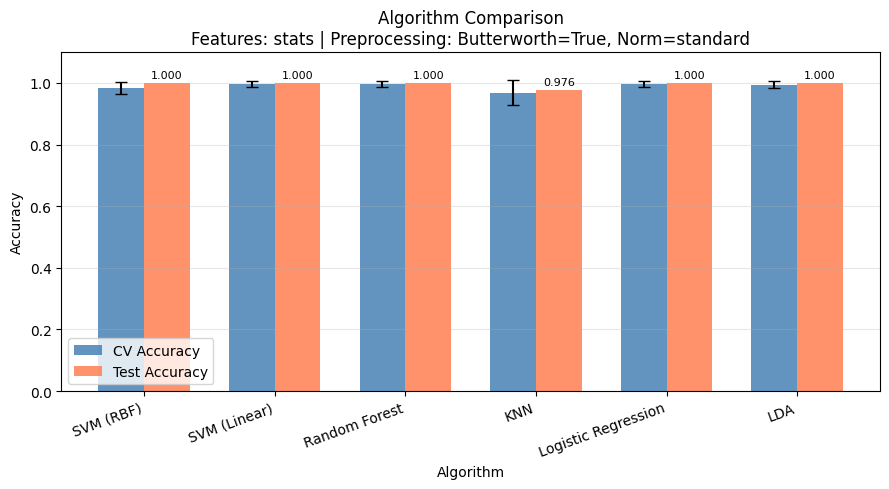

In [146]:
# ── Bar chart: CV vs Test accuracy ────────────────────────────────────────────

names      = list(results.keys())
cv_means   = [results[n]['cv_mean']  for n in names]
cv_stds    = [results[n]['cv_std']   for n in names]
test_accs  = [results[n]['test_acc'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(max(8, len(names) * 1.5), 5))
bars1 = ax.bar(x - width/2, cv_means, width, yerr=cv_stds,
               label='CV Accuracy', color='steelblue', capsize=4, alpha=0.85)
bars2 = ax.bar(x + width/2, test_accs, width,
               label='Test Accuracy', color='coral', alpha=0.85)

ax.set_xlabel('Algorithm')
ax.set_ylabel('Accuracy')
ax.set_title(f'Algorithm Comparison\n'
             f'Features: {FEATURE_MODE} | '
             f'Preprocessing: Butterworth={APPLY_BUTTERWORTH}, Norm={NORMALISATION}')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

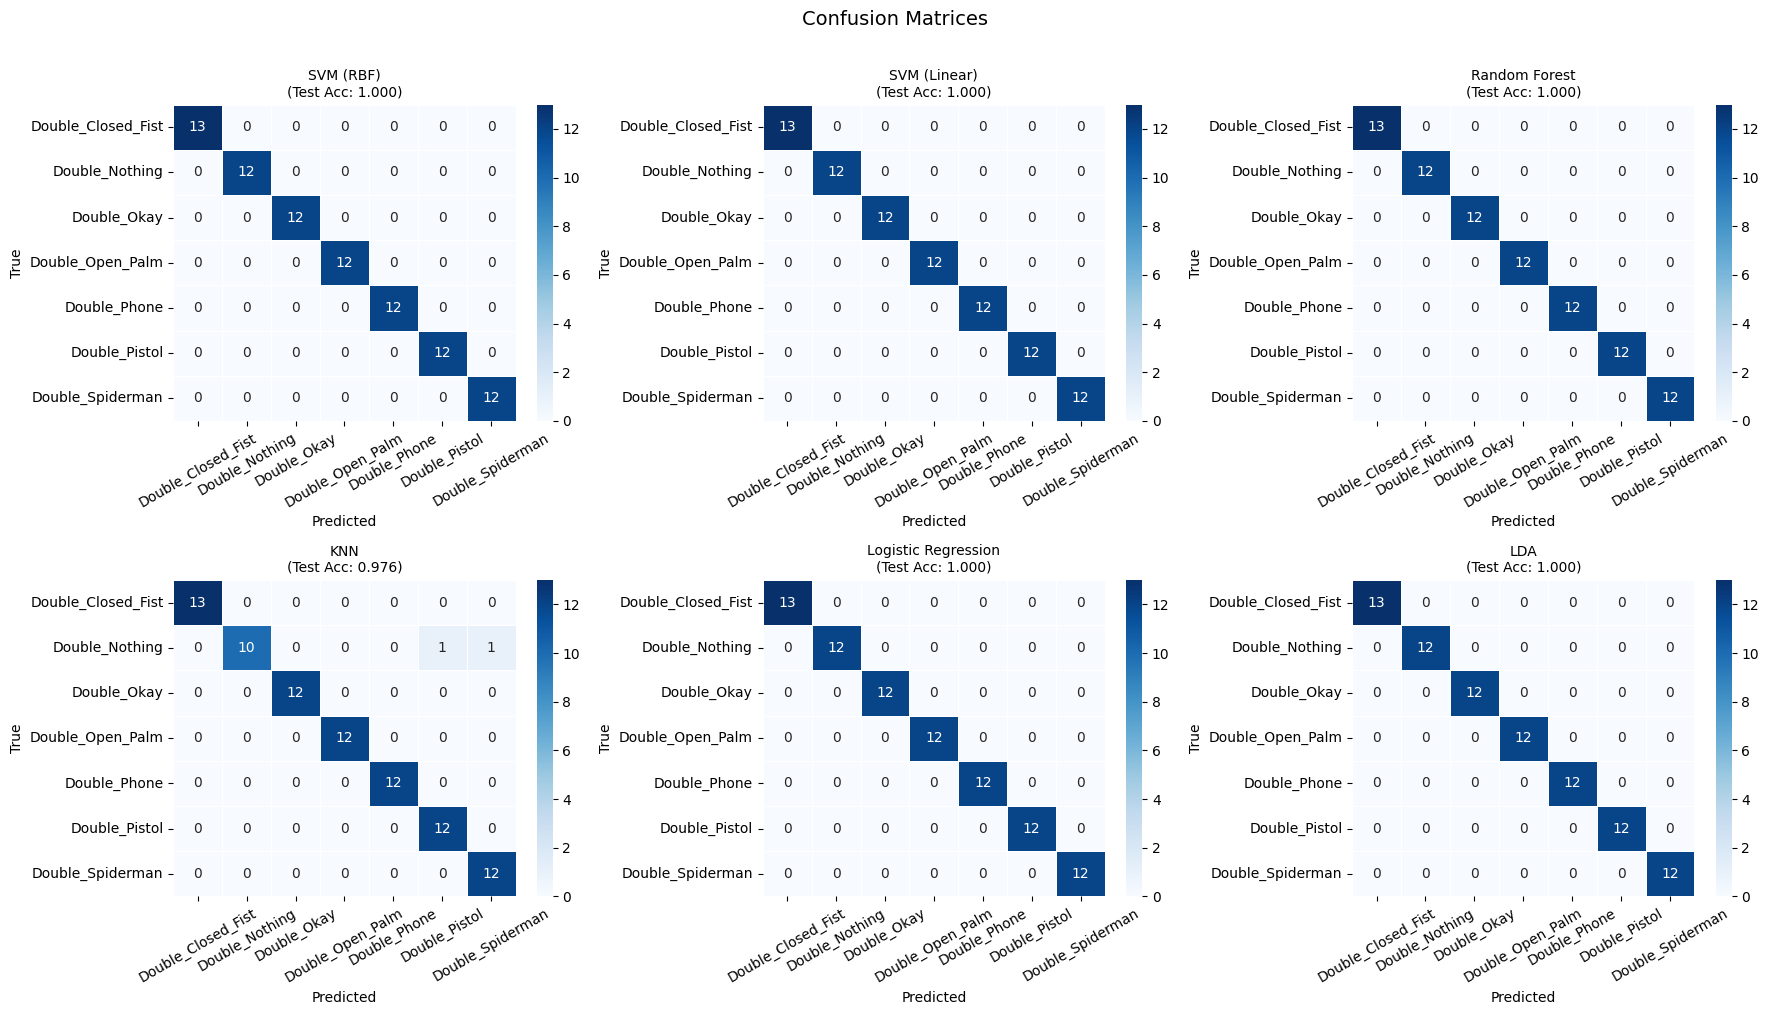

In [147]:
# ── Confusion matrices for all active classifiers ────────────────────────────

n_clf = len(results)
ncols = min(3, n_clf)
nrows = (n_clf + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten() if n_clf > 1 else [axes]

short_labels = [lbl.replace('TwoHand_', '').replace('TwoHandDynamic_', 'Dyn_') for lbl in le.classes_]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=short_labels, yticklabels=short_labels,
                linewidths=0.5)
    ax.set_title(f'{name}\n(Test Acc: {res["test_acc"]:.3f})', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

# Hide unused subplots
for ax in axes[n_clf:]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

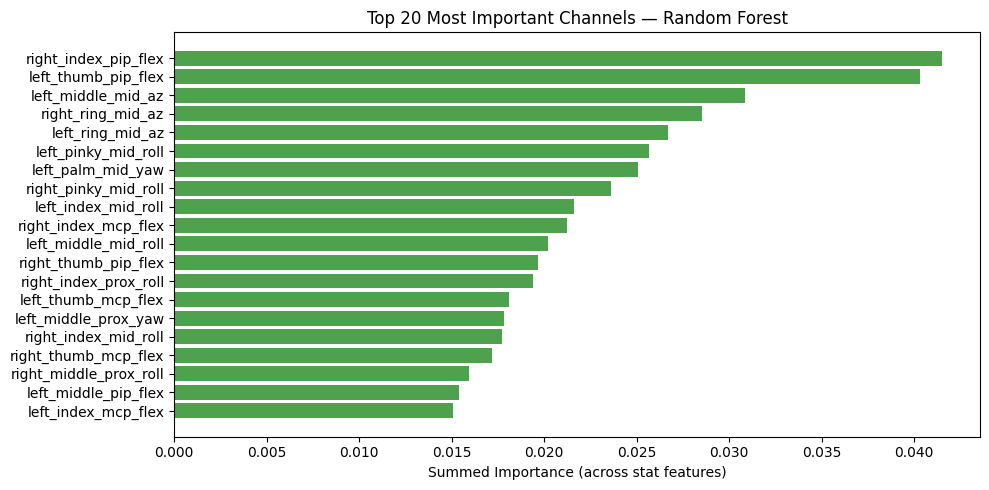

In [148]:
# ── Feature importance (Random Forest) ───────────────────────────────────────

if 'Random Forest' in results:
    rf = results['Random Forest']['clf']
    importances = rf.feature_importances_

    # Map feature indices back to channel names
    n_ch = len(SENSOR_COLS)
    stat_names = ['mean', 'std', 'min', 'max', 'range', 'rms', 'skew', 'kurtosis']

    if FEATURE_MODE == 'stats':
        # importances shape: (8 * n_ch,) — group by channel
        ch_importance = importances.reshape(len(stat_names), n_ch).sum(axis=0)
        top_n = 20
        top_idx = np.argsort(ch_importance)[::-1][:top_n]

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.barh([SENSOR_COLS[i] for i in top_idx[::-1]],
                ch_importance[top_idx[::-1]], color='forestgreen', alpha=0.8)
        ax.set_xlabel('Summed Importance (across stat features)')
        ax.set_title(f'Top {top_n} Most Important Channels — Random Forest')
        plt.tight_layout()
        plt.show()
    else:
        top_n = 30
        top_idx = np.argsort(importances)[::-1][:top_n]
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(range(top_n), importances[top_idx], color='forestgreen', alpha=0.8)
        ax.set_xlabel('Feature index (top 30)')
        ax.set_ylabel('Importance')
        ax.set_title('Top 30 Feature Importances — Random Forest')
        plt.tight_layout()
        plt.show()
else:
    print('Random Forest not enabled — skipping feature importance plot.')

---
## 7. Experiment Log

Use this cell to record what you tried and what worked.

| # | Hands | Segments | Modalities | Feature Mode | Filter | Norm | Best Algorithm | Test Acc | Notes |
|---|-------|----------|------------|--------------|--------|------|----------------|----------|-------|
| 1 | both  | all      | YPR+Flex   | stats        | 5 Hz   | std  |                |          |       |

---
## Notes

**Suggested experiments to try:**

1. **Flex only** — Set `USE_YAW_PITCH_ROLL=False`, `USE_ACCELEROMETER=False`, `USE_FLEX_SENSORS=True`. See if flex alone is sufficient for static gestures.
2. **IMU only** — Opposite: disable flex, keep YPR + accel.
3. **Single hand** — Set `INCLUDE_HANDS=['left']` vs `['right']` to check hand asymmetry.
4. **FFT features** — Change `FEATURE_MODE='fft'` — useful for dynamic gestures (Flapping).
5. **No filter** — Set `APPLY_BUTTERWORTH=False` to see noise impact.
6. **Quaternion channels** — For `TwoHand_L_Flat_R_Flat`, enable `USE_QUATERNIONS=True` and disable YPR.
7. **Wrist only** — Reduce `INCLUDE_SEGMENTS=['wrist']` — minimal sensor configuration.

---
## 8. Manual Sample Testing

Load one or more CSV files and run them through the **exact same preprocessing pipeline** used during training, then predict with all trained classifiers.

Use this to:
- Test a freshly recorded trial that was **not in the training set**
- Verify real-world generalisation
- Diagnose which gestures are being confused

> **Prerequisite:** Run all cells above first (Sections 1–4) so the classifiers, scaler, and pipeline are in memory.

In [149]:
# =============================================================================
# 7A. TEST SAMPLE CONFIGURATION
# =============================================================================

# Path(s) to CSV files you want to test.
# Can be a single file or a list of files.
# The true label (ground truth) is optional — set to None if unknown.

TEST_SAMPLES = [
    {
        'path':  'path/to/your/test_trial.csv',   # <-- update this
        'label': 'TwoHand_L_Fist_R_Fist',         # true label, or None
    },
    # Add more samples as needed:
    # {'path': 'path/to/another.csv', 'label': None},
]

print(f'Test samples configured: {len(TEST_SAMPLES)}')
for s in TEST_SAMPLES:
    print(f'  {s["path"]}  →  label={s["label"]}')

Test samples configured: 1
  path/to/your/test_trial.csv  →  label=TwoHand_L_Fist_R_Fist


In [150]:
# =============================================================================
# 7B. PREPROCESS + PREDICT
# =============================================================================

def preprocess_sample(fpath, sensor_cols, resample_n, apply_butter, cutoff, order, fs):
    """Load a single CSV and apply the same preprocessing as training."""
    if not os.path.isfile(fpath):
        raise FileNotFoundError(f'File not found: {fpath}')

    df = pd.read_csv(fpath)

    # Select sensor columns (only those available in this file)
    available = [c for c in sensor_cols if c in df.columns]
    missing   = [c for c in sensor_cols if c not in df.columns]
    if missing:
        print(f'  NOTE: {len(missing)} expected columns not found in this file (will be zero-filled):')
        print(f'    {missing[:5]}{" ..." if len(missing) > 5 else ""}')

    # Build array, zero-fill missing columns
    data = np.zeros((len(df), len(sensor_cols)), dtype=np.float32)
    for i, col in enumerate(sensor_cols):
        if col in df.columns:
            data[:, i] = df[col].values.astype(np.float32)

    # Resample
    if resample_n is not None:
        data = resample_trial(data, resample_n)

    # Butterworth filter
    if apply_butter:
        data = apply_butterworth([data], cutoff, order, fs)[0]

    return data


def predict_sample(data, feature_mode, fs, scaler, classifiers):
    """Extract features and predict with all trained classifiers."""
    # Feature extraction
    if feature_mode == 'flatten':
        feats = data.flatten()
    elif feature_mode == 'stats':
        feats = extract_stats(data)
    elif feature_mode == 'fft':
        feats = extract_fft(data, fs)
    elif feature_mode == 'stats+fft':
        feats = np.concatenate([extract_stats(data), extract_fft(data, fs)])

    feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)
    feats_scaled = scaler.transform(feats.reshape(1, -1))  # apply same scaler as training

    predictions = {}
    for name, res in classifiers.items():
        clf = res['clf']
        pred_idx = clf.predict(feats_scaled)[0]
        pred_label = le.inverse_transform([pred_idx])[0]
        # Confidence (probability) if supported
        if hasattr(clf, 'predict_proba'):
            proba = clf.predict_proba(feats_scaled)[0]
            confidence = proba.max()
        elif hasattr(clf, 'decision_function'):
            df_vals = clf.decision_function(feats_scaled)[0]
            if df_vals.ndim == 0:
                confidence = float(abs(df_vals))
            else:
                confidence = float(abs(df_vals).max())
        else:
            confidence = None
        predictions[name] = (pred_label, confidence)

    return predictions


# ── Run prediction on each test sample ───────────────────────────────────────
print('=' * 70)
for sample in TEST_SAMPLES:
    fpath      = sample['path']
    true_label = sample.get('label', None)

    print(f'\nFile: {os.path.basename(fpath)}')
    print(f'True label: {true_label if true_label else "unknown"}')
    print('-' * 50)

    try:
        data = preprocess_sample(
            fpath        = fpath,
            sensor_cols  = SENSOR_COLS,
            resample_n   = RESAMPLE_TO_N_STEPS,
            apply_butter = APPLY_BUTTERWORTH,
            cutoff       = BUTTERWORTH_CUTOFF,
            order        = BUTTERWORTH_ORDER,
            fs           = SAMPLING_RATE_HZ,
        )

        preds = predict_sample(
            data         = data,
            feature_mode = FEATURE_MODE,
            fs           = SAMPLING_RATE_HZ,
            scaler       = scaler,
            classifiers  = results,
        )

        for clf_name, (pred, conf) in preds.items():
            correct = '✓' if (true_label and pred == true_label) else ('✗' if true_label else '')
            conf_str = f'{conf:.3f}' if conf is not None else 'N/A'
            print(f'  {clf_name:<22} →  {pred:<35} conf={conf_str}  {correct}')

    except Exception as e:
        print(f'  ERROR: {e}')

print('\n' + '=' * 70)


File: test_trial.csv
True label: TwoHand_L_Fist_R_Fist
--------------------------------------------------
  ERROR: File not found: path/to/your/test_trial.csv



## Test

In [151]:
TEST_ROOT = os.path.expanduser(
    "/home/jestin/ThesisRepo/ML/NewTestData/Georgia/Static"  # <- adjust if needed
)

# /home/jestin/ThesisData/TestData/Ameline



In [152]:
# ── Evaluate trained models on separate test dataset ───────────────────────────

# import os
# import glob
# import numpy as np
# import pandas as pd
# from collections import Counter
# from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


# Root of your external / unseen test dataset.
# This directory should contain one folder per class label.
# TEST_ROOT = os.path.expanduser(
#     "/home/jestin/ThesisData/TestData/Ameline"  # <- adjust if needed
# )


def load_external_dataset(data_root, sensor_cols, known_classes):
    """
    Load external test data using the SAME folder-name labelling method
    as the main training dataset loader.

    Important difference:
    - If a folder name is not recognised from training, skip the whole folder.
    - Print a message saying that folder/class will not be included.
    """
    data_root = os.path.expanduser(data_root)

    # Make sure the external test root exists
    if not os.path.isdir(data_root):
        raise FileNotFoundError(f"TEST_ROOT not found: '{data_root}'")

    # Find all subfolders under the test root
    label_dirs = sorted([
        d for d in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, d))
        and d not in ("PDF", "sdb", "idk")
    ])

    # If no folders are found, the path or structure is wrong
    if not label_dirs:
        raise ValueError(f"No label folders found under {data_root}")

    print(f"Found {len(label_dirs)} external test gesture folders:")
    trials, labels = [], []

    # Track skipped folders for reporting
    skipped_folders = []

    # Loop over each folder, where the folder name is the class label
    for label in label_dirs:
        folder = os.path.join(data_root, label)

        # If the folder/class name was not seen during training, skip the whole folder
        if label not in known_classes:
            print(f"Label folder '{label}' is not recognised from training, so it will not be included.")
            skipped_folders.append(label)
            continue

        # Get all CSV files inside this recognised label folder
        csv_files = sorted(glob.glob(os.path.join(folder, "*.csv")))
        print(f" [{label}] → {len(csv_files)} files")

        # Load every CSV in the folder as one trial
        for fpath in csv_files:
            try:
                df = pd.read_csv(fpath)

                # Keep only the sensor columns selected earlier in the notebook
                available = [c for c in sensor_cols if c in df.columns]
                if not available:
                    print(f" WARNING: no matching sensor columns in {os.path.basename(fpath)}")
                    continue

                # Convert the selected columns to a numeric array
                trial = df[available].values.astype(np.float32)

                # Store the trial and its label
                trials.append(trial)
                labels.append(label)

            except Exception as e:
                # If one CSV fails, log it and continue with the others
                print(f" ERROR loading {os.path.basename(fpath)}: {e}")

    # If any folders were skipped, print a short summary
    if skipped_folders:
        print("\nSkipped unrecognised label folders:")
        for label in skipped_folders:
            print(f" {label}")

    print(f"\nTotal recognised external test trials loaded: {len(trials)}")
    print("Recognised external test class distribution:")
    for cls, cnt in sorted(Counter(labels).items()):
        print(f" {cls}: {cnt} trials")

    return trials, labels


# Build a set of class names that were seen during training
# le was created earlier in the notebook from the training labels
known_classes = set(le.classes_)

# 1. Load recognised external test folders only
ext_trials_raw, ext_labels_raw = load_external_dataset(
    TEST_ROOT,
    SENSOR_COLS,
    known_classes
)

# If no recognised folders produced any usable trials, stop here
if len(ext_trials_raw) == 0:
    raise ValueError("No recognised external test samples were loaded.")

# 2. Apply the SAME preprocessing pipeline used in training

# 2a. Resample / interpolate every trial to the fixed number of time steps
if RESAMPLE_TO_N_STEPS is not None:
    ext_trials_resampled = [resample_trial(t, RESAMPLE_TO_N_STEPS) for t in ext_trials_raw]
else:
    ext_trials_resampled = ext_trials_raw

# 2b. Apply Butterworth low-pass filtering if enabled
if APPLY_BUTTERWORTH:
    ext_trials_filtered = apply_butterworth(
        ext_trials_resampled,
        BUTTERWORTH_CUTOFF,
        BUTTERWORTH_ORDER,
        SAMPLING_RATE_HZ
    )
else:
    ext_trials_filtered = ext_trials_resampled

# 2c. Extract features using the same feature mode as training
X_ext = extract_features(ext_trials_filtered, FEATURE_MODE, SAMPLING_RATE_HZ)

# 2d. Clean up NaN / Inf values just like in training
bad = np.isnan(X_ext) | np.isinf(X_ext)
if bad.any():
    print(f"WARNING: {bad.sum()} NaN/Inf values found in external test set — replacing with 0.")
    X_ext = np.nan_to_num(X_ext, nan=0.0, posinf=0.0, neginf=0.0)

print(
    f"External test feature matrix shape: "
    f"{X_ext.shape} ({X_ext.shape[0]} trials × {X_ext.shape[1]} features)"
)

# 3. Encode the recognised external labels using the SAME LabelEncoder as training
y_ext = le.transform(ext_labels_raw)
print("Encoded external test labels with existing LabelEncoder `le`.")

# 4. Apply the SAME scaler used during training
if NORMALISATION in ("standard", "minmax"):
    X_ext_scaled = scaler.transform(X_ext)
else:
    X_ext_scaled = X_ext

# 5. Evaluate every trained classifier on the external test set
print("\n=== External Test Set Evaluation ===")

external_results = []   # overall accuracy per classifier
external_per_class = {} # per-class accuracy array per classifier

for name, res in results.items():
    clf = res["clf"]

    # Predict external test labels
    y_pred_ext = clf.predict(X_ext_scaled)

    # Overall accuracy
    acc_ext = accuracy_score(y_ext, y_pred_ext)

    # Save accuracy for summary table
    external_results.append({
        "Algorithm": name,
        "External Test Acc": f"{acc_ext:.4f}"
    })

    # Per-class accuracy from confusion matrix (order = le.classes_)
    cm_ext = confusion_matrix(
        y_ext,
        y_pred_ext,
        labels=np.arange(len(le.classes_))
    )
    correct = np.diag(cm_ext)
    total = cm_ext.sum(axis=1)

    class_acc = np.divide(
        correct,
        total,
        out=np.zeros_like(correct, dtype=float),
        where=total != 0
    )
    external_per_class[name] = class_acc

# 6. Tabulate external test accuracies
external_summary = pd.DataFrame(external_results)
external_summary = external_summary.sort_values("External Test Acc", ascending=False).reset_index(drop=True)

print("\n=== External Test Accuracy Summary ===")
print(external_summary.to_string(index=False))

# 7. Wide per-class accuracy table: rows = class, cols = classifier
class_names = le.classes_
ext_per_class_df = pd.DataFrame({'Finger': class_names})

for name, class_acc in external_per_class.items():
    ext_per_class_df[name] = class_acc

print("\n=== External Test Per-Class Accuracy Table ===")
print(ext_per_class_df.to_string(index=False))

Found 7 external test gesture folders:
 [Double_Closed_Fist] → 5 files
 [Double_Nothing] → 5 files
 [Double_Okay] → 5 files
 [Double_Open_Palm] → 5 files
 [Double_Phone] → 5 files
 [Double_Pistol] → 5 files
 [Double_Spiderman] → 5 files

Total recognised external test trials loaded: 35
Recognised external test class distribution:
 Double_Closed_Fist: 5 trials
 Double_Nothing: 5 trials
 Double_Okay: 5 trials
 Double_Open_Palm: 5 trials
 Double_Phone: 5 trials
 Double_Pistol: 5 trials
 Double_Spiderman: 5 trials
External test feature matrix shape: (35, 1408) (35 trials × 1408 features)
Encoded external test labels with existing LabelEncoder `le`.

=== External Test Set Evaluation ===

=== External Test Accuracy Summary ===
          Algorithm External Test Acc
                KNN            0.5714
Logistic Regression            0.5429
       SVM (Linear)            0.4571
      Random Forest            0.4286
                LDA            0.3143
          SVM (RBF)            0.2571

==